# Demo

- https://github.com/IntelligentSensingAndRehabilitation/MonocularBiomechanics/tree/5befd88686c48d979e826ec2da7ced0df3da61fc

In [72]:
import os, sys
import numpy as np
import equinox as eqx
from tqdm import tqdm, trange
from typing import Tuple, Dict
from matplotlib import pyplot as plt

"""
Setting for GPU acceleration
"""
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false" # limit jax and TF from consuming all GPU memory

# Tensorflow
import tensorflow as tf
import tensorflow_hub as hub

# Jax
import jax
jax.config.update("jax_enable_x64", True)
from jax import numpy as jnp
from jaxtyping import Float, Array
import optax

# Mujoco
from mujoco import mjx

# Custom Libraries

In [ ]:
from video_tool import get_video_frames

# Params

In [15]:
home_dir_path = "/home/seojin/biomechanics_tools/MonocularBiomechanics"
data_dir_path = os.path.join(home_dir_path, "data")
skeleton_type = 'bml_movi_87'

In [18]:
sys.path.append(home_dir_path)

In [21]:
lib_dir_path = "/home/seojin/Seojin_commonTool/Module"
sys.path.append(lib_dir_path)

# Load video datas

- MoVi: A Large Multipurpose Motion and Video Dataset

In [3]:
video_path = os.path.join(data_dir_path, "running_sagittal.mp4")
frames = get_video_frames(video_path)

# Human Pose Estimation

## Initialize HPE model
- MeTRaBS

In [4]:
hpe_model = hub.load('https://bit.ly/metrabs_l')

# Get the joint names and the edges
joint_names = hpe_model.per_skeleton_joint_names[skeleton_type].numpy().astype(str)
joint_edges = hpe_model.per_skeleton_joint_edges[skeleton_type].numpy()

I0000 00:00:1785765195.006593 3946135 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22179 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:21:00.0, compute capability: 8.6
I0000 00:00:1785765195.009526 3946135 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22341 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:49:00.0, compute capability: 8.6


## Perform HPE

In [55]:
batch_size = 8

accumulated = None
for i in range(0, len(frames), batch_size):
    batch = frames[i:i+batch_size]
    pred = hpe_model.detect_poses_batched(batch, skeleton=skeleton)
    
    if accumulated is None:
        accumulated = pred

    else:
        # concatenate the ragged tensor along the batch for each element in the dictionary
        for key in accumulated.keys():
            accumulated[key] = tf.concat([accumulated[key], pred[key]], axis=0)

## Preproces pose data

In [58]:
num_people = [p.shape[0] for p in accumulated['poses2d']]

# assert this is 1 for all the frames
assert len(set(num_people)) == 1

# then extract the information for that person
boxes = np.array([p[0] for p in accumulated['boxes']])
pose3d = np.array([p[0] for p in accumulated['poses3d']])
pose2d = np.array([p[0] for p in accumulated['poses2d']])

In [ ]:
# convert pose to m
pose = pose3d
pose = pose[:, :, [0, 2, 1]]
pose[:, :, 2] *= -1
pose /= 1000.0

pose = pose - np.min(pose, axis=1, keepdims=True)

timestamps = jnp.arange(len(pose)) / 30.0

dataset = (timestamps, pose)

# Now compute kinematics end-to-end using a differentiable body model

This uses an implicit representation $f_\theta: t \rightarrow \theta \in \mathbb R^{40}$, which is then passed through the forward kinematic model to get the predicted 3D keypoints: $\mathcal M_\beta: \theta \rightarrow \mathbf y \in \mathbb R^{87 \times 3}$.

We optimize the difference between the predicted 3D keypoints and the detected 3D keypoints.

In [66]:
from monocular_demos.biomechanics_mjx.monocular_trajectory import KineticsWrapper, get_default_wrapper

In [ ]:
# construct a loss function between the forward pass through the forward kinematic
# implicit representation and the resulting keypoint and the detected keypoitns
def loss(
    model: KineticsWrapper,
    x: Float[Array, "times"],
    y: Float[Array, "times keypoints 3"],
    site_offset_regularization = 1e-1
) -> Tuple[Float, Dict]:

    timestamps = x
    keypoints3d = y
    metrics = {}

    # NOTE: steps is an make sure this retraces for different dimensions
    (state, constraints, next_states), (ang, vel, action), _ = model(
        timestamps,
        skip_vel=True,
        skip_action=True,
    )

    pred_kp3d = state.site_xpos

    l = jnp.mean((pred_kp3d - keypoints3d) ** 2) * 100 # so in cm
    metrics["kp_err"] = l

    # regularize marker offset
    l_site_offset = jnp.sum(jnp.square(model.site_offsets))
    l += l_site_offset * site_offset_regularization

    # make loss the first key in the dictionary by popping and building a new dictionary with the rest
    metrics = {"loss": l, **metrics}

    return l, metrics

In [ ]:
@eqx.filter_jit
def step(model, opt_state, data, loss_grad, optimizer, **kwargs):
    x, targets = data

    (val, metrics), grads = loss_grad(model, x=x, y=targets, **kwargs)
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_inexact_array))
    model = eqx.apply_updates(model, updates)
    return val, model, opt_state, metrics

In [ ]:
def fit_model(
    model: KineticsWrapper,
    dataset: Tuple,
    lr_end_value: float = 1e-8,
    lr_init_value: float = 1e-4,
    max_iters: int = 5000,
    clip_by_global_norm: float = 0.1,
):

    # work out the transition steps to make the desired schedule
    transition_steps = 10
    lr_decay_rate = (lr_end_value / lr_init_value) ** (1.0 / (max_iters // transition_steps))
    learning_rate = optax.warmup_exponential_decay_schedule(
        init_value=0,
        warmup_steps=0,
        peak_value=lr_init_value,
        end_value=lr_end_value,
        decay_rate=lr_decay_rate,
        transition_steps=transition_steps,
    )

    optimizer = optax.chain(
        optax.adamw(learning_rate=learning_rate, b1=0.8, weight_decay=1e-5), optax.zero_nans(), optax.clip_by_global_norm(clip_by_global_norm)
    )
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

    loss_grad = eqx.filter_value_and_grad(loss, has_aux=True)

    counter = trange(max_iters)
    for i in counter:

        val, model, opt_state, metrics = step(model, opt_state, dataset, loss_grad, optimizer)

        if i > 0 and i % int(max_iters // 10) == 0:
            print(f"iter: {i} loss: {val}.")  # metrics: {metrics}")

        if i % 50 == 0:
            metrics = {k: v.item() for k,v in metrics.items()}
            print(val, metrics)

    return model, metrics

In [67]:
fkw = get_default_wrapper()
updated_model, metrics = fit_model(fkw, dataset)

/home/seojin/biomechanics_tools/MonocularBiomechanics/monocular_demos/biomechanics_mjx/monocular_trajectory.py:299: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  fkw = KineticsWrapper(fk, scale_mixer=scale_mixer, key=jax.random.PRNGKey(0))
  0%|          | 1/5000 [00:22<30:57:49, 22.30s/it]

15.718140839886159 {'kp_err': 15.718140839886159, 'loss': 15.718140839886159}


  2%|▏         | 77/5000 [00:33<13:48,  5.94it/s]  

1.2930223176887123 {'kp_err': 1.2929653411570892, 'loss': 1.2930223176887123}
0.19775877562873895 {'kp_err': 0.19764481648033713, 'loss': 0.19775877562873895}


  4%|▎         | 181/5000 [00:34<02:32, 31.51it/s]

...

0.011748872167947157 {'kp_err': 0.009261705969991818, 'loss': 0.011748872167947157}
0.01174937764501357 {'kp_err': 0.009262050536422359, 'loss': 0.01174937764501357}


 98%|█████████▊| 4902/5000 [00:52<00:00, 257.10it/s]

0.01174833399794414 {'kp_err': 0.009260858552410082, 'loss': 0.01174833399794414}
0.01174845815813807 {'kp_err': 0.00926084601947082, 'loss': 0.01174845815813807}


100%|██████████| 5000/5000 [00:53<00:00, 94.19it/s] 

0.011748310827304386 {'kp_err': 0.009260572704515828, 'loss': 0.011748310827304386}


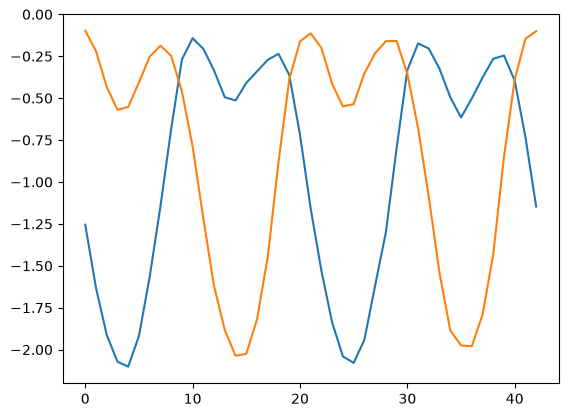

In [68]:
(state, constraints, next_states), (ang, vel, action), _ = updated_model(dataset[0], skip_vel=True, skip_action=True)
jnp.mean((state.site_xpos.shape - dataset[1]) ** 2)

# plot the knees
plt.figure()
plt.plot(ang[:, [9, 16]]);

In [ ]:
from monocular_demos.biomechanics_mjx.visualize import render_trajectory, jupyter_embed_video

fn = 'reconstruction.mp4'
render_trajectory(ang, fn, xml_path=None)
HTML = jupyter_embed_video(fn)
HTML

In [84]:
from monocular_demos.biomechanics_mjx.forward_kinematics import (
        ForwardKinematics,
        offset_sites,
        scale_model,
        set_margin,
        shift_geom_vertically,
    )

# Test

In [87]:
fk = ForwardKinematics(xml_path=None)
model = fk.model
model = set_margin(model, margin = None)

In [88]:
scale_model(model, 1)

<function monocular_demos.biomechanics_mjx.forward_kinematics.scale_model(model: mujoco.mjx._src.types.Model, scale: jaxtyping.Float[Array, 'bodies 1'] | jaxtyping.Float) -> mujoco.mjx._src.types.Model>

In [ ]:

        if heel_vertical_offset is not None:
            heel_geom_names = [
                "l_foot_col1",
                "l_foot_col3",
                "r_foot_col1",
                "r_foot_col3",
            ]
            heel_idx = np.array([fk.geom_names.index(g) for g in heel_geom_names])
            model = shift_geom_vertically(model, heel_idx, heel_vertical_offset)

    if body_scale is not None:
        scale = 1 + fk.build_default_scale_mixer() @ body_scale
        model = scale_model(model, scale)

    if site_offsets is not None:
        model = offset_sites(model, site_offsets)

    data = mujoco.MjData(model)

    scene_option = mujoco.MjvOption()
    # scene_option.flags[mujoco.mjtVisFlag.mjVIS_JOINT] = True
    if show_grfs:
        scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
        scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
        scene_option.flags[mujoco.mjtVisFlag.mjVIS_COM] = True
        if actuators is not None:
            scene_option.flags[mujoco.mjtVisFlag.mjVIS_ACTIVATION] = True
            scene_option.flags[mujoco.mjtVisFlag.mjVIS_ACTUATOR] = True

    if blank_background is not None:
        model.tex_data = np.zeros_like(model.tex_data) + blank_background

    if not shadow:
        scene_option.flags[mujoco.mjtVisFlag.mjVIS_STATIC] = False
        scene_option.flags[mujoco.mjtRndFlag.mjRND_SHADOW] = False

    if hide_tendon:
        scene_option.flags[mujoco.mjtVisFlag.mjVIS_TENDON] = False

    # remove weird overlay
    geom_1_indices = np.where(model.geom_group == 1)
    model.geom_rgba[geom_1_indices, 3] = 0

    camera = mujoco.MjvCamera()
    camera.distance = 3
    camera.azimuth = azimuth
    camera.elevation = -20

    renderer = mujoco.Renderer(model, height=height, width=width)

    images = []
    for i in trange(len(pose)):
        if isinstance(pose, list):
            # when we are passed a list of mj_data just use them
            data = pose[i]

            # relight as otherwise super dark
            mujoco.mj_camlight(model, data)

        else:
            data.qpos = pose[i]
            mujoco.mj_forward(model, data)

        if i == 0:
            camera.lookat = data.xpos[1]
        else:
            camera.lookat = camera.lookat * 0.7 + data.xpos[1] * 0.3

        if actuators is not None:
            data.ctrl = data.ctrl * 0.0
            data.act = actuators[i]

        renderer.update_scene(data, camera=camera, scene_option=scene_option)
        images.append(renderer.render())

    if filename is not None:
        import cv2
        import numpy as np

        cap = cv2.VideoWriter(
            filename, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height)
        )

        for i in trange(len(images)):
            # fix the color channels
            img = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
            cap.write(img)

        cap.release()

    else:
        return images

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


100%|██████████| 43/43 [00:00<00:00, 650.52it/s]
